# Learning Magic‑Formula Parameters with a Conditional DDIM
This notebook shows **a minimal working example** of using a *conditional Denoising Diffusion Implicit Model (DDIM)* to learn the four parameters (B, C, D, E) of the Pacejka *Magic Formula* for the friction–slip curve of an anti‑lock braking system (ABS), **conditioned on five noisy measurements**.

⚠️ *Because we only condition on five data points, this is purely an educational toy example—not production code.*

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from torch.optim import lr_scheduler
import torch.optim as optim

batch_size = 64
n_cond = 5

In [2]:

def magic_formula(slip, params):
    """Return mu given slip (tensor) and params = (B,C,D,E)."""
    B, C, D, E = params.unbind(-1)
    return D * torch.sin( C * torch.atan( B*slip - E*(B*slip - torch.atan(B*slip)) ) )


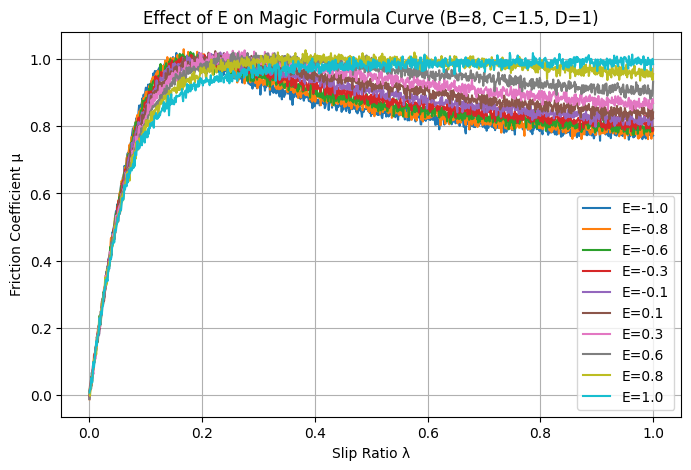

In [3]:
# Fixed parameters
B = 8.0
C = 1.5
D = 1.0

# Range of E values to visualize
E_values = np.linspace(-1, 1, 10)

slip_range = np.linspace(0, 1, 1000)
plt.figure(figsize=(8, 5))
for E in E_values:
    params = torch.tensor([B, C, D, E])
    mu = magic_formula(torch.tensor(slip_range, dtype=torch.float32), params)
    mu = mu + 0.01 * torch.randn_like(mu)
    plt.plot(slip_range, mu.numpy(), label=f"E={E:.1f}")

plt.xlabel('Slip Ratio λ')
plt.ylabel('Friction Coefficient μ')
plt.title('Effect of E on Magic Formula Curve (B=8, C=1.5, D=1)')
plt.legend()
plt.grid(True)
plt.show()

In [4]:

def make_batch(batch_size=64, n_cond=n_cond, noise_std=0.05, device='cpu', slip_range=(0.05, 0.4)):
    """Generate a batch of (params, condition) pairs.

    * params: true (B,C,D,E) ∈ ℝ⁴
    * condition: 5 noisy (slip, mu) pairs flattened to length‑10 vector
    """
    # Sample random ground‑truth parameters from realistic ranges
    B = torch.empty(batch_size, 1).uniform_(4.0, 12.0)
    C = torch.empty(batch_size, 1).uniform_(1.0, 2.0)
    D = torch.empty(batch_size, 1).uniform_(0.1, 1.9)
    E = torch.empty(batch_size, 1).uniform_(-1.0, 1.0)
    params = torch.cat([B, C, D, E], dim=1)

    # slip = (torch.rand(batch_size, n_cond)) * (slip_range[1] - slip_range[0])  + slip_range[0]
    # slip = torch.tensor(np.linspace(slip_range[0], slip_range[1], n_cond))
    slip = torch.linspace(slip_range[0], slip_range[1], n_cond).repeat(batch_size, 1)
    sorted_slip, _ = torch.sort(slip, dim=1)
    mu = magic_formula(sorted_slip, params.unsqueeze(1).expand(-1, n_cond, -1))
    mu_noisy = mu + noise_std * torch.randn_like(mu)

    cond = torch.cat([slip, mu_noisy], dim=-1).reshape(batch_size, 2, -1)
    return params.to(device), cond.to(device)


/var/folders/50/2xnlv1wx4_91lvzqtbrvx_yc0000gn/T/ipykernel_7949/372557188.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


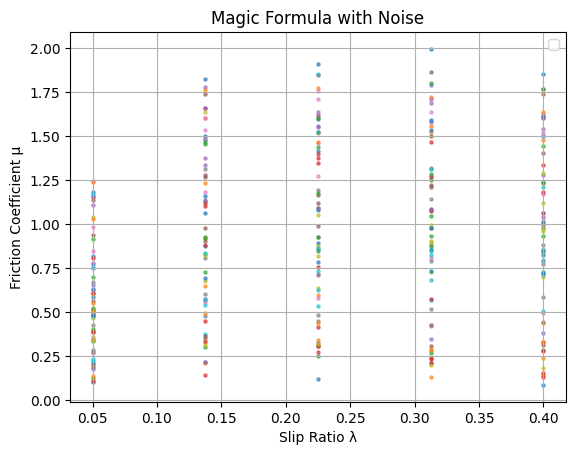

In [5]:
data_param, data_slip = make_batch(batch_size, n_cond, noise_std=0.05)
# data_slip = data_slip.reshape(batch_size, -1, 2)
for i in range(batch_size):
    slips, mu_noisy = data_slip[i, 0, :], data_slip[i, 1, :]
    
    # Plot the Magic Formula
    plt.scatter(slips, mu_noisy, alpha=0.6, s=5)

plt.xlabel('Slip Ratio λ')
plt.ylabel('Friction Coefficient μ')
plt.title('Magic Formula with Noise')
plt.grid(True)
plt.legend()
plt.show()

In [6]:

## Diffusion schedule
T = 1000
beta_start, beta_end = 1e-4, 0.025
betas = torch.linspace(beta_start, beta_end, T)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

# print(alphas_cumprod)

range_b = (4.0, 12.0)
range_c = (1.0, 2.0)
range_d = (0.1, 1.9)
range_e = (-1.0, 1.0)
scale = torch.tensor([range_b[1] - range_b[0], range_c[1] - range_c[0],
                      range_d[1] - range_d[0], range_e[1] - range_e[0]]).to(data_param.device)
shift = torch.tensor([range_b[0], range_c[0],
                      range_d[0], range_e[0]]).to(data_param.device)


In [7]:

def q_sample(x0, t, noise=None):
    """Diffusion forward process q(x_t | x_0)."""
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_alphas_cumprod = (alphas_cumprod[t]**0.5).unsqueeze(1).expand_as(x0)
    sqrt_one_minus_alphas_cumprod = ((1 - alphas_cumprod[t])**0.5).unsqueeze(1).expand_as(x0)
    
    return sqrt_alphas_cumprod * x0 + sqrt_one_minus_alphas_cumprod * noise, noise


In [8]:

class CondMLP(nn.Module):
    def __init__(self, cond_dim=n_cond, x_dim=4, hidden1=128, hidden2=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(x_dim + cond_dim + 1, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.Sigmoid(),
            nn.Linear(hidden2, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, x_dim)
        )
        # self.net = nn.Sequential(
        #     nn.Linear(x_dim + cond_dim + 1, 3200),
        #     nn.Sigmoid(),
        #     # nn.Linear(hidden1, hidden2),
        #     # nn.ReLU(),
        #     # nn.Linear(hidden2, hidden2),
        #     # nn.ReLU(),
        #     nn.Linear(3200, x_dim)
        # )
    def forward(self, x_t, t, cond):
        # Embed timestep as (t / T) to 1‑D scalar
        t_embed = (t.float() / T).unsqueeze(-1)
        inp = torch.cat([x_t, cond, t_embed], dim=-1)
        return self.net(inp)


In [9]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CondMLP().to(device)
# Initialize a learning rate scheduler (e.g., StepLR)
optimizer = torch.optim.RMSprop(model.parameters(), lr=1e-3)
scheduler = lr_scheduler.StepLR(optimizer, step_size=100000, gamma=0.1)
epochs, batch_size = 300000, 1024

for step in range(1, epochs+1):
    params_0, cond = make_batch(batch_size, device=device, noise_std=0.0)
    slips, mu_true = cond[:, 0, :], cond[:, 1, :]

    t = torch.randint(0, T, (batch_size,), device=device)
    x_t, noise = q_sample(params_0, t)
    noise_pred = model(x_t, t, mu_true.reshape(batch_size, -1))
    
    
    alpha_bar = alphas_cumprod[t].unsqueeze(-1).expand_as(x_t)
    # Predict x_0
    x0_pred = (x_t - torch.sqrt(1 - alpha_bar) * noise_pred) / torch.sqrt(alpha_bar)
    
    params_0_adj = (params_0 - shift) / scale
    x0_pred_adj = (x0_pred - shift) / scale
    
    # loss = F.mse_loss(noise_pred, noise) + F.mse_loss(x0_pred_adj, params_0_adj)
    loss = F.mse_loss(x0_pred_adj, params_0_adj)
    

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Update the learning rate
    scheduler.step()

    if step % 1000 == 0:
        print(f"step {step:5d} | loss {loss.item():.4e}")
        


step  1000 | loss 2.4219e+01
step  2000 | loss 9.3314e+01
step  3000 | loss 1.0077e+01
step  4000 | loss 4.0558e+00
step  5000 | loss 1.2117e+01
step  6000 | loss 6.0139e+00
step  7000 | loss 4.7969e+00
step  8000 | loss 6.0902e+00
step  9000 | loss 1.2787e+01
step 10000 | loss 1.1818e+01
step 11000 | loss 9.3657e+00
step 12000 | loss 4.8000e+00
step 13000 | loss 4.3202e+00
step 14000 | loss 1.3235e+00
step 15000 | loss 1.8886e+00
step 16000 | loss 3.5949e+00
step 17000 | loss 1.6355e+01
step 18000 | loss 1.2004e+00
step 19000 | loss 7.5766e+00
step 20000 | loss 1.1168e+00
step 21000 | loss 4.4013e+00
step 22000 | loss 2.3129e+00
step 23000 | loss 4.0455e+00
step 24000 | loss 9.4000e+00
step 25000 | loss 3.1804e+01
step 26000 | loss 2.7312e+00
step 27000 | loss 6.5829e+00
step 28000 | loss 2.4053e+00
step 29000 | loss 1.3807e+00
step 30000 | loss 9.7144e-01
step 31000 | loss 9.8925e-01
step 32000 | loss 1.1823e+00
step 33000 | loss 8.1025e-01
step 34000 | loss 1.4231e+00
step 35000 | l

In [10]:

@torch.no_grad()
def ddim_sample(cond, n_steps=1000, eta=0.0):
    x = torch.randn(cond.shape[0], 4, device=cond.device)
    step_size = T // n_steps
    for i in range(T-1, -1, -step_size):
        t = torch.full((cond.size(0),), i, device=cond.device, dtype=torch.long)
        noise_pred = model(x, t, cond)

        alpha_bar = alphas_cumprod[i]
        alpha = alphas[i]
        i_prev = max(i - step_size, 0)
        alpha_bar_prev = alphas_cumprod[i_prev]

        # Predict x_0
        x0_pred = (x - torch.sqrt(1 - alpha_bar) * noise_pred) / torch.sqrt(alpha_bar)


        # DDIM coefficients
        sigma = 0.0
        if eta > 0:
            sigma = (
                eta
                * torch.sqrt((1 - alpha_bar_prev) / (1 - alpha_bar))
                * torch.sqrt(1 - alpha_bar / alpha_bar_prev)
            )

        dir_xt = torch.sqrt(alpha_bar_prev) * x0_pred
        noise_xt = torch.sqrt(1 - alpha_bar_prev - sigma**2) * noise_pred
        x = dir_xt + noise_xt
        if eta > 0:
            x = x + sigma * torch.randn_like(x)
    return x0_pred


In [11]:
def sample_params():
    B = torch.empty(1, 1).uniform_(4.0, 12.0)
    C = torch.empty(1, 1).uniform_(1.0, 2.0)
    D = torch.empty(1, 1).uniform_(0.1, 1.9)
    E = torch.empty(1, 1).uniform_(-1.0, 1.0)
    return torch.cat([B, C, D, E], dim=1)

In [12]:

# Ground‑truth parameters
true_params, cond_test = make_batch(1, n_cond, noise_std=0.03)
slips, mu_true = cond_test[:, 0, :], cond_test[:, 1, :]

# DDIM inference
est_params = ddim_sample(mu_true.reshape(1, -1), n_steps=T, eta=0.01).cpu().squeeze()
print(f"True  : {true_params.cpu().squeeze().tolist()}")
print(f"Est.  : {est_params.tolist()}")


True  : [10.741491317749023, 1.3019042015075684, 0.8127132654190063, -0.2503194808959961]
Est.  : [10.30858039855957, 1.357552409172058, 0.7038944363594055, 1.052718997001648]


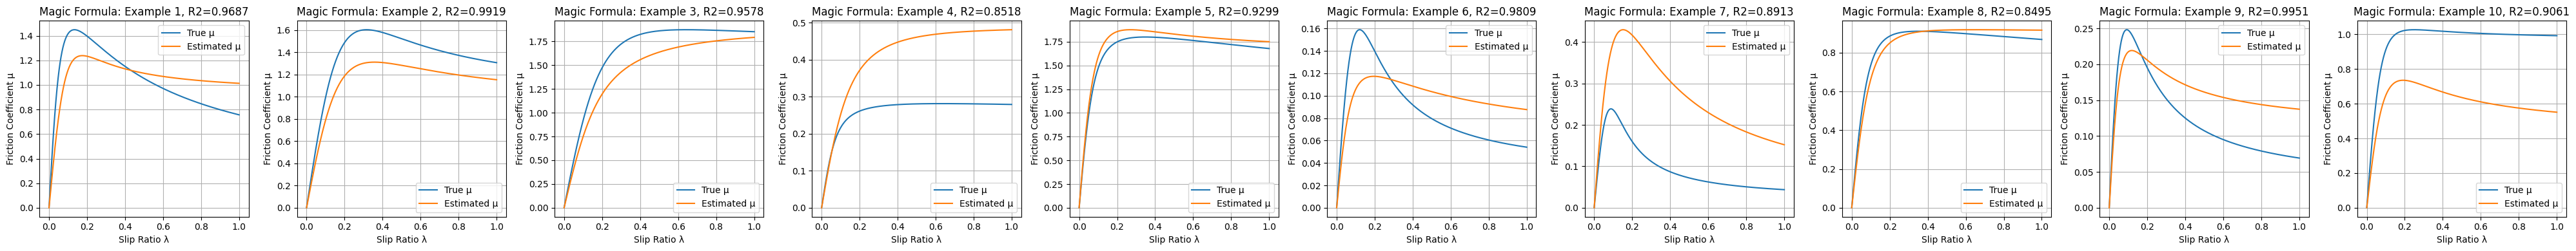

In [13]:
sample_size = 1000
slips = np.linspace(0, 1, sample_size)
fig, axes = plt.subplots(1, 10, figsize=(40, 4))
for i in range(10):
    # Generate new ground-truth parameters and noisy condition
    true_params_i, cond_test_i = make_batch(1, n_cond, noise_std=0.0)
    slips_i, mu_true_i = cond_test_i[:, 0, :], cond_test_i[:, 1, :]
    # Estimate parameters using DDIM
    est_params_i = ddim_sample(mu_true_i.reshape(1, -1), n_steps=T).cpu().squeeze()
    
    params_mse = F.mse_loss(est_params_i, true_params_i.squeeze())
    params_r2 = 1 - params_mse / torch.var(true_params_i.squeeze())
    # Compute mu for a range of slips
    mu_true_i = magic_formula(torch.tensor(slips, dtype=torch.float32), true_params_i).cpu().numpy()
    mu_est_i = magic_formula(torch.tensor(slips, dtype=torch.float32), est_params_i).cpu().numpy()
    # Plot
    axes[i].plot(slips, mu_true_i, label='True μ')
    axes[i].plot(slips, mu_est_i, label='Estimated μ')
    axes[i].set_xlabel('Slip Ratio λ')
    axes[i].set_ylabel('Friction Coefficient μ')
    axes[i].set_title(f'Magic Formula: Example {i+1}, R2={params_r2.item():.4f}')
    axes[i].legend()
    axes[i].grid(True)
plt.tight_layout()
plt.show()

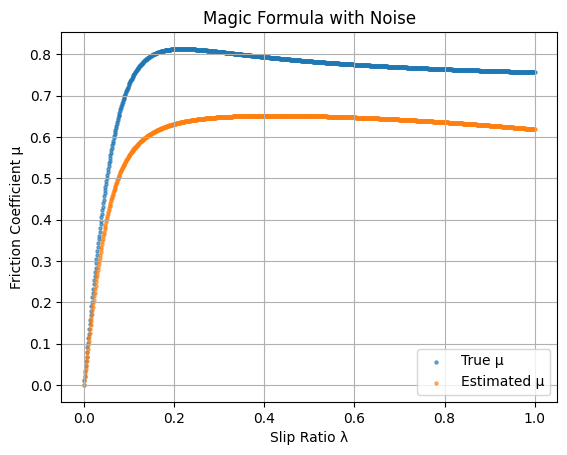

In [14]:
sample_size = 1000
slips = np.linspace(0, 1, sample_size)
mu_true = magic_formula(torch.tensor(slips, dtype=torch.float32), true_params).cpu().numpy()
mu_est = magic_formula(torch.tensor(slips, dtype=torch.float32), est_params).cpu().numpy()

# Plot the Magic Formula
plt.scatter(slips, mu_true, alpha=0.6, s=5, label='True μ')
plt.scatter(slips, mu_est, alpha=0.6, s=5, label='Estimated μ')

plt.xlabel('Slip Ratio λ')
plt.ylabel('Friction Coefficient μ')
plt.title('Magic Formula with Noise')
plt.grid(True)
plt.legend()
plt.show()

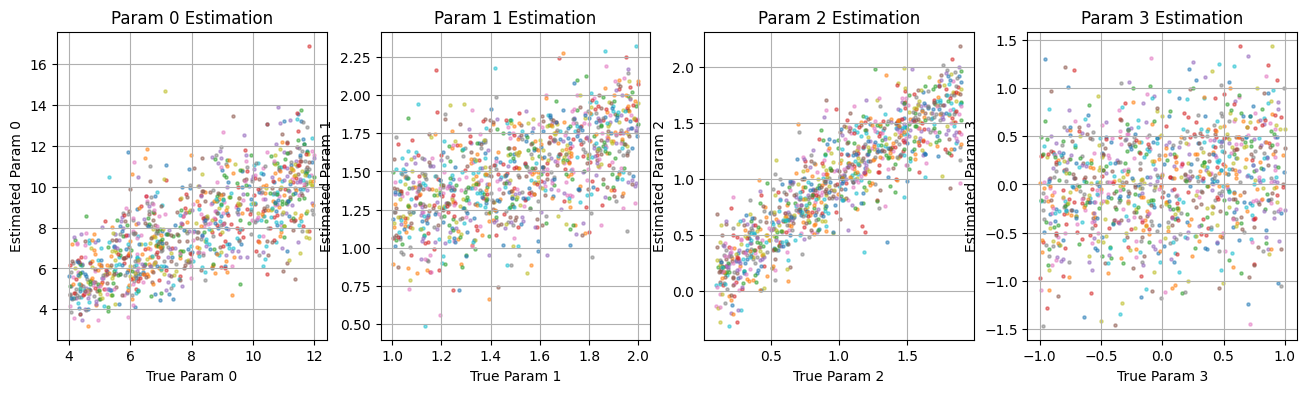

b r2: tensor(0.4776)
c r2: tensor(0.1088)
d r2: tensor(0.7814)
e r2: tensor(-0.4457)


In [15]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

bs_true = []
bs_pred = []
cs_true = []
cs_pred = []
ds_true = []
ds_pred = []
es_true = []
es_pred = []

for i in range(1000):
    # Generate new ground-truth parameters and noisy condition
    true_params_i, cond_test_i = make_batch(1, n_cond, noise_std=0.0)
    slips_i, mu_true_i = cond_test_i[:, 0, :], cond_test_i[:, 1, :]
    # Estimate parameters using DDIM
    est_params_i = ddim_sample(mu_true_i.reshape(1, -1), n_steps=T).cpu().squeeze()
    
    bs_true.append(true_params_i[0, 0].item())
    bs_pred.append(est_params_i[0].item())
    cs_true.append(true_params_i[0, 1].item())
    cs_pred.append(est_params_i[1].item())
    ds_true.append(true_params_i[0, 2].item())
    ds_pred.append(est_params_i[2].item())
    es_true.append(true_params_i[0, 3].item())
    es_pred.append(est_params_i[3].item())
    
    
    for j in range(4):
        axes[j].scatter(true_params_i[0][j].item(), est_params_i[j].item(), alpha=0.5, s=5)
        axes[j].set_xlabel(f'True Param {j}')
        axes[j].set_ylabel(f'Estimated Param {j}')
        axes[j].set_title(f'Param {j} Estimation')
        axes[j].grid(True)

# plt.legend()
plt.show()

print("b r2:", 1 - F.mse_loss(torch.tensor(bs_pred), torch.tensor(bs_true)) / torch.var(torch.tensor(bs_true)))
print("c r2:", 1 - F.mse_loss(torch.tensor(cs_pred), torch.tensor(cs_true)) / torch.var(torch.tensor(cs_true)))
print("d r2:", 1 - F.mse_loss(torch.tensor(ds_pred), torch.tensor(ds_true)) / torch.var(torch.tensor(ds_true)))
print("e r2:", 1 - F.mse_loss(torch.tensor(es_pred), torch.tensor(es_true)) / torch.var(torch.tensor(es_true)))

## Next Steps
* Increase the training data size and epochs for better accuracy.
* Replace the simple MLP with a richer network (e.g. sinusoidal timestep embedding, FiLM‑style conditional layers).
* Explore alternative conditioning tricks such as cross‑attention.
* Try other diffusion formulations (e.g. Score‑SDE, DPM‑Solver) for faster sampling.